# TA7 - Trackstars

Rubric 
- A python package for feature engineering is demonstrated
- A small dataset for testing purposes is either a built-in dataset, accessible via a python package, or added to the data/ repository
- Code is a script, not a notebook
- Code is clean and well organized
- Code is documented with docstrings and comments 
- Code is free of commented out code (ie debug print statements)
- Script has a clear name
- Branching and PRs were done appropriately
- Requirements are included in the text of the PR and are correct and versioned
- The code runs as documented

❗️ Any demo code will need to be migrated to a streamlit app or similar for the assignment. 

In [1]:
# The instinct here is to engineer general and dataset-specific features 
# that might improve our ability to do classification with this dataset

In [67]:
# See overview of pytorch dataset interactions here: 
# https://pytorch.org/tutorials/beginner/basics/data_tutorial.html

import torch 
from torch.utils.data import Dataset
from torchvision.datasets import FGVCAircraft

import cv2

In [68]:
import matplotlib.pyplot as plt 

In [69]:
# See overview of built-in FGVCAircraft interface here: 
# https://pytorch.org/vision/main/generated/torchvision.datasets.FGVCAircraft.html#torchvision.datasets.FGVCAircraft
#
# ... and the implementation here: 
# https://pytorch.org/vision/0.12/_modules/torchvision/datasets/fgvc_aircraft.html
#
# annotation_level is one of 'variant', 'family' or 'manufacturer', in descending order of 
# granularity

training_data = FGVCAircraft(
    root = 'data',
    annotation_level = 'family', 
    download = True
) 

100.0%


Extracting data/fgvc-aircraft-2013b.tar.gz to data


In [70]:
len(training_data) 

6667

In [46]:
# Dataset has an image and an int, these can be retrieved by indexing the 
# object or passing an index to __getitem__ ... 

In [71]:
training_data[0]

(<PIL.Image.Image image mode=RGB size=1024x695>, 12)

In [72]:
display(training_data.__getitem__(0))

(<PIL.Image.Image image mode=RGB size=1024x695>, 12)

In [73]:
sample = training_data[1459]

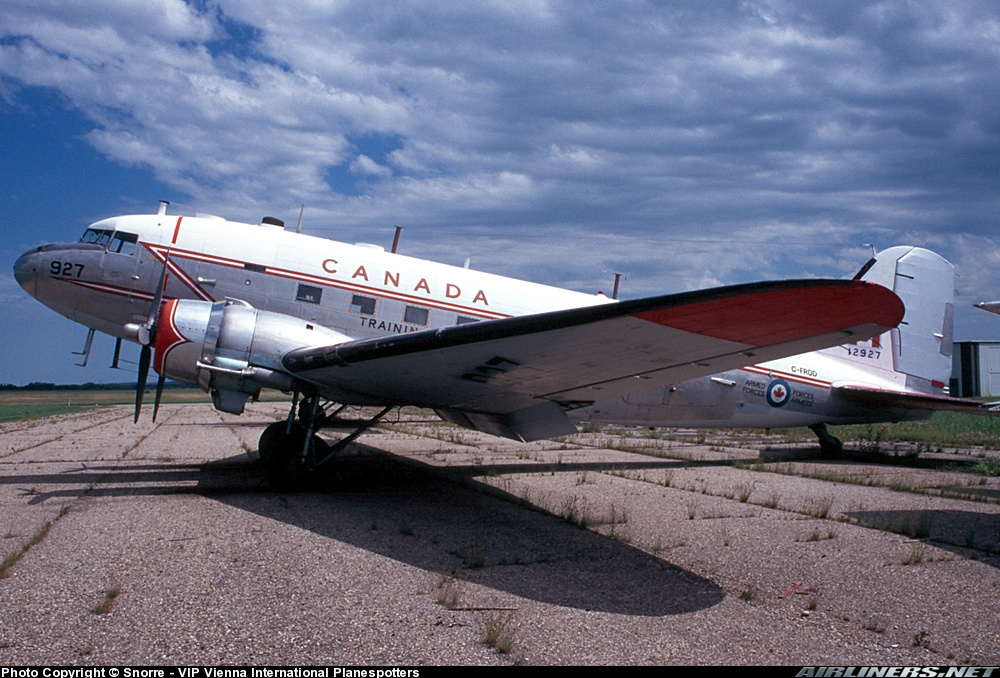

In [74]:
# Image in the first part of the tuple... 
sample[0]

In [75]:
# 'Target' appears to be encoded in the int, we specified 'class' above so 
# presume this is the class of this image
sample[1]

21

In [76]:
training_data.classes[sample[1]]

'C-47'

In [77]:
# Peeking at the implementation gives us insight into the labels parsed 
# from the on-disk dataset... class_to_idx will always map to whatever 
# level of category we specified in the constructor (here 'family'). E.g. 
# we can't now retrieve manufacturer of the sample without creating a new 
# instance or digging around in the dataset files

for i, c in enumerate(training_data.class_to_idx): 
    if i == sample[1]: 
        print(c) 

C-47


In [78]:
def render_sample(index): 
    sample = training_data[index] 

    category = training_data.classes[sample[1]]
        
    print(f"Category of sample #{index} is {category}")
    display(sample[0])

Category of sample #556 is Boeing 767


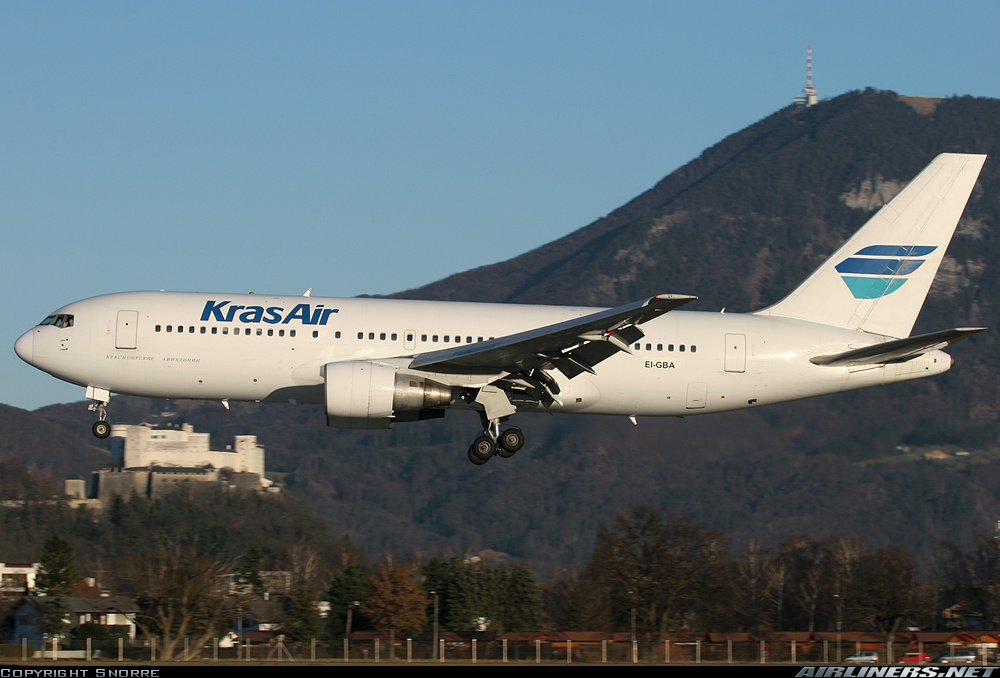

In [79]:
render_sample(556)

# Corner Detection

Providing corners to neural network would conceivably avoid having to learn a similar feature during training 

In [80]:
import PIL
import numpy as np

In [81]:
# Convert PIL format to CV2-compatible nparry-based image and shift to
# grayscale (required for corner detection algorithm)
img = np.array(sample[0]) 
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

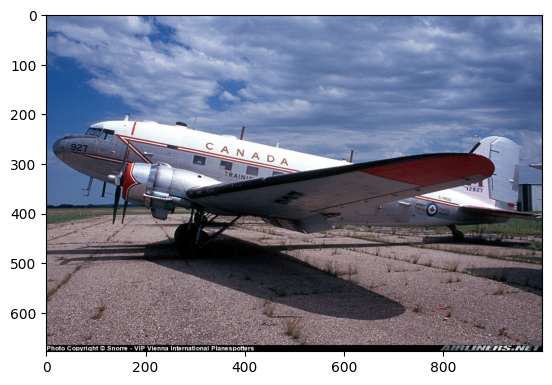

In [82]:
plt.imshow(img)

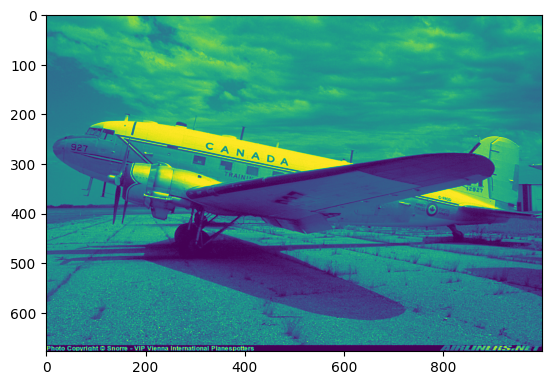

In [83]:
plt.imshow(gray)

In [84]:
# Examples courtesy of https://docs.opencv.org/4.x/dc/d0d/tutorial_py_features_harris.html
corners = cv2.cornerHarris(
    gray,        # Grayscale float32 image
    blockSize=5, # Neighborhood considered for a corner
    ksize=3,     # Aperture of the Sobel derivative
    k=0.6        # Harris detector free parameter (??) 
) 

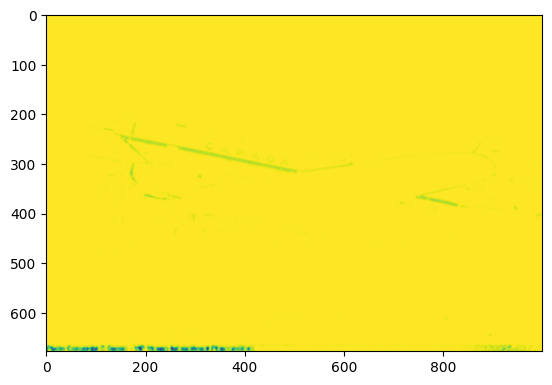

In [85]:
plt.imshow(corners) 

In [127]:
# Hmm... this isn't working, must be missing something on how to call out the corners here... 

In [86]:
img[corners > 0.001 * corners.max()] = [255,0,255]

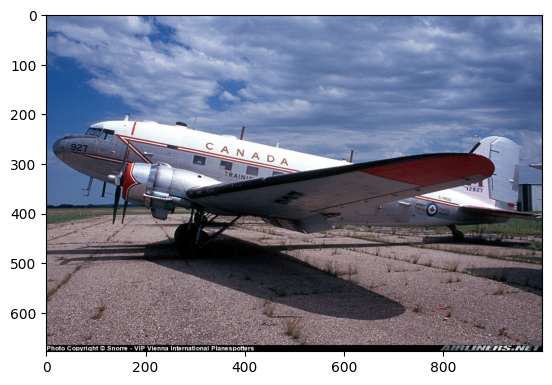

In [87]:
plt.imshow(img) 

In [89]:
img = np.array(sample[1]) 

# Edge Detection

Let's try and perform some edge detection on a sample image

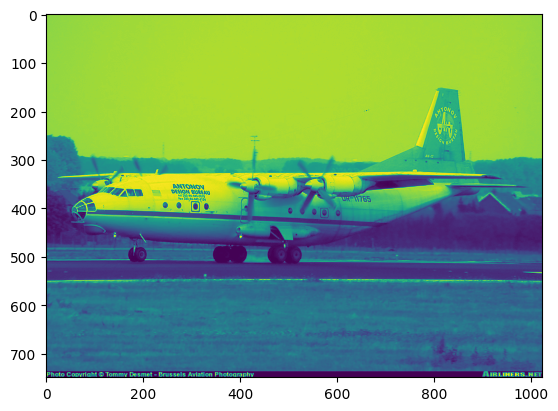

In [94]:
sample = training_data[1222]

img = np.array(sample[0]) 
grey = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

plt.imshow(grey)

Apply a Gaussian blur to reduce noise and detail

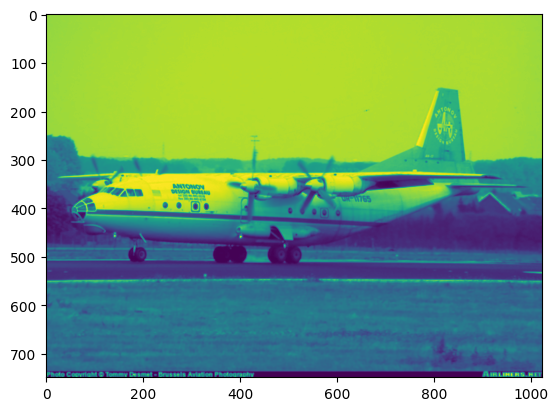

In [95]:
blurred_image = cv2.GaussianBlur(grey, (5, 5), 0)
plt.imshow(blurred_image)

Perform edge detection

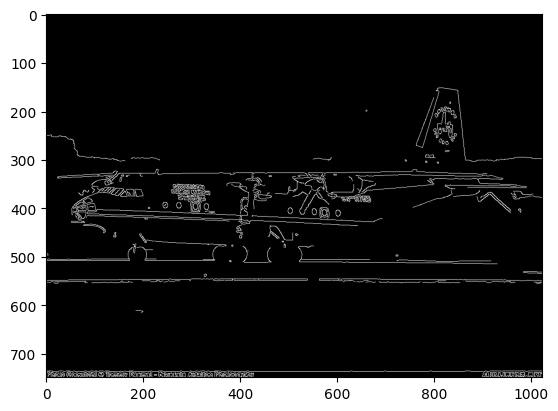

In [103]:
edges = cv2.Canny(blurred_image, threshold1=100, threshold2=200)

plt.imshow(edges, cmap="gray")

# SIFT (Scale-Invariant Feature Transform)

SIFT is essentially a 'key point' detector, this would be useful in the planes dataset because idetifying different planes often depends on these key points like engine size, tail shape etc.

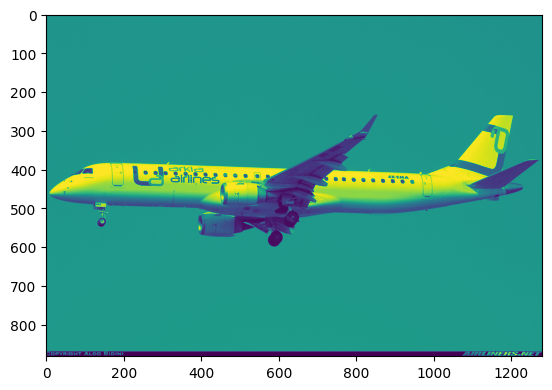

In [104]:
sample = training_data[5555]

img = np.array(sample[0]) 
grey = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

plt.imshow(grey)

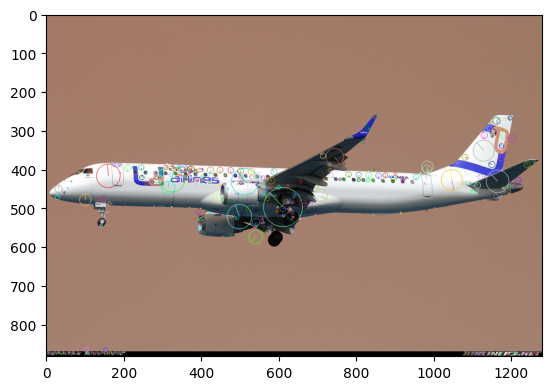

In [105]:
sift = cv2.SIFT_create()
keypoints, descriptors = sift.detectAndCompute(grey, None)
output_image = cv2.drawKeypoints(img, keypoints, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

plt.imshow(cv2.cvtColor(output_image, cv2.COLOR_BGR2RGB))
